# 학습 조건 비교와 해석
동일 분할·seed 2026에서 E02·E03·E07–E11 결과를 비교한다. 이 노트북은 저장 결과를 읽으며 시험 데이터로 모델을 선택하지 않는다.

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "src").is_dir():
    raise RuntimeError("Open the notebook from the repository or notebooks directory")
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))


In [2]:
import csv
from IPython.display import display, Image
rows = list(csv.DictReader((ROOT / "reports/experiment_summary.csv").open(encoding="utf-8")))
for row in rows:
    print(row)

{'experiment': 'E02', 'name': 'Feature MLP', 'accuracy': '0.916056338028169', 'macro_f1': '0.9138316445580504', 'parameters': '80582', 'input_shape': '[561]', 'best_epoch': '2', 'epochs_ran': '8', 'train_seconds': '4.771637400001055', 'best_val_loss': '0.2847193479537964'}
{'experiment': 'E03', 'name': 'Sequence MLP', 'accuracy': '0.8783098591549295', 'macro_f1': '0.8765305887108537', 'parameters': '156230', 'input_shape': '[128, 9]', 'best_epoch': '4', 'epochs_ran': '10', 'train_seconds': '5.751154300000053', 'best_val_loss': '0.39916524291038513'}
{'experiment': 'E07', 'name': 'No standardization', 'accuracy': '0.8873239436619719', 'macro_f1': '0.8863985548577257', 'parameters': '80582', 'input_shape': '[561]', 'best_epoch': '2', 'epochs_ran': '8', 'train_seconds': '4.747117200000503', 'best_val_loss': '0.2650938928127289'}
{'experiment': 'E08', 'name': 'Dropout 0.3', 'accuracy': '0.8952112676056339', 'macro_f1': '0.8939527148516359', 'parameters': '80582', 'input_shape': '[561]', 'b

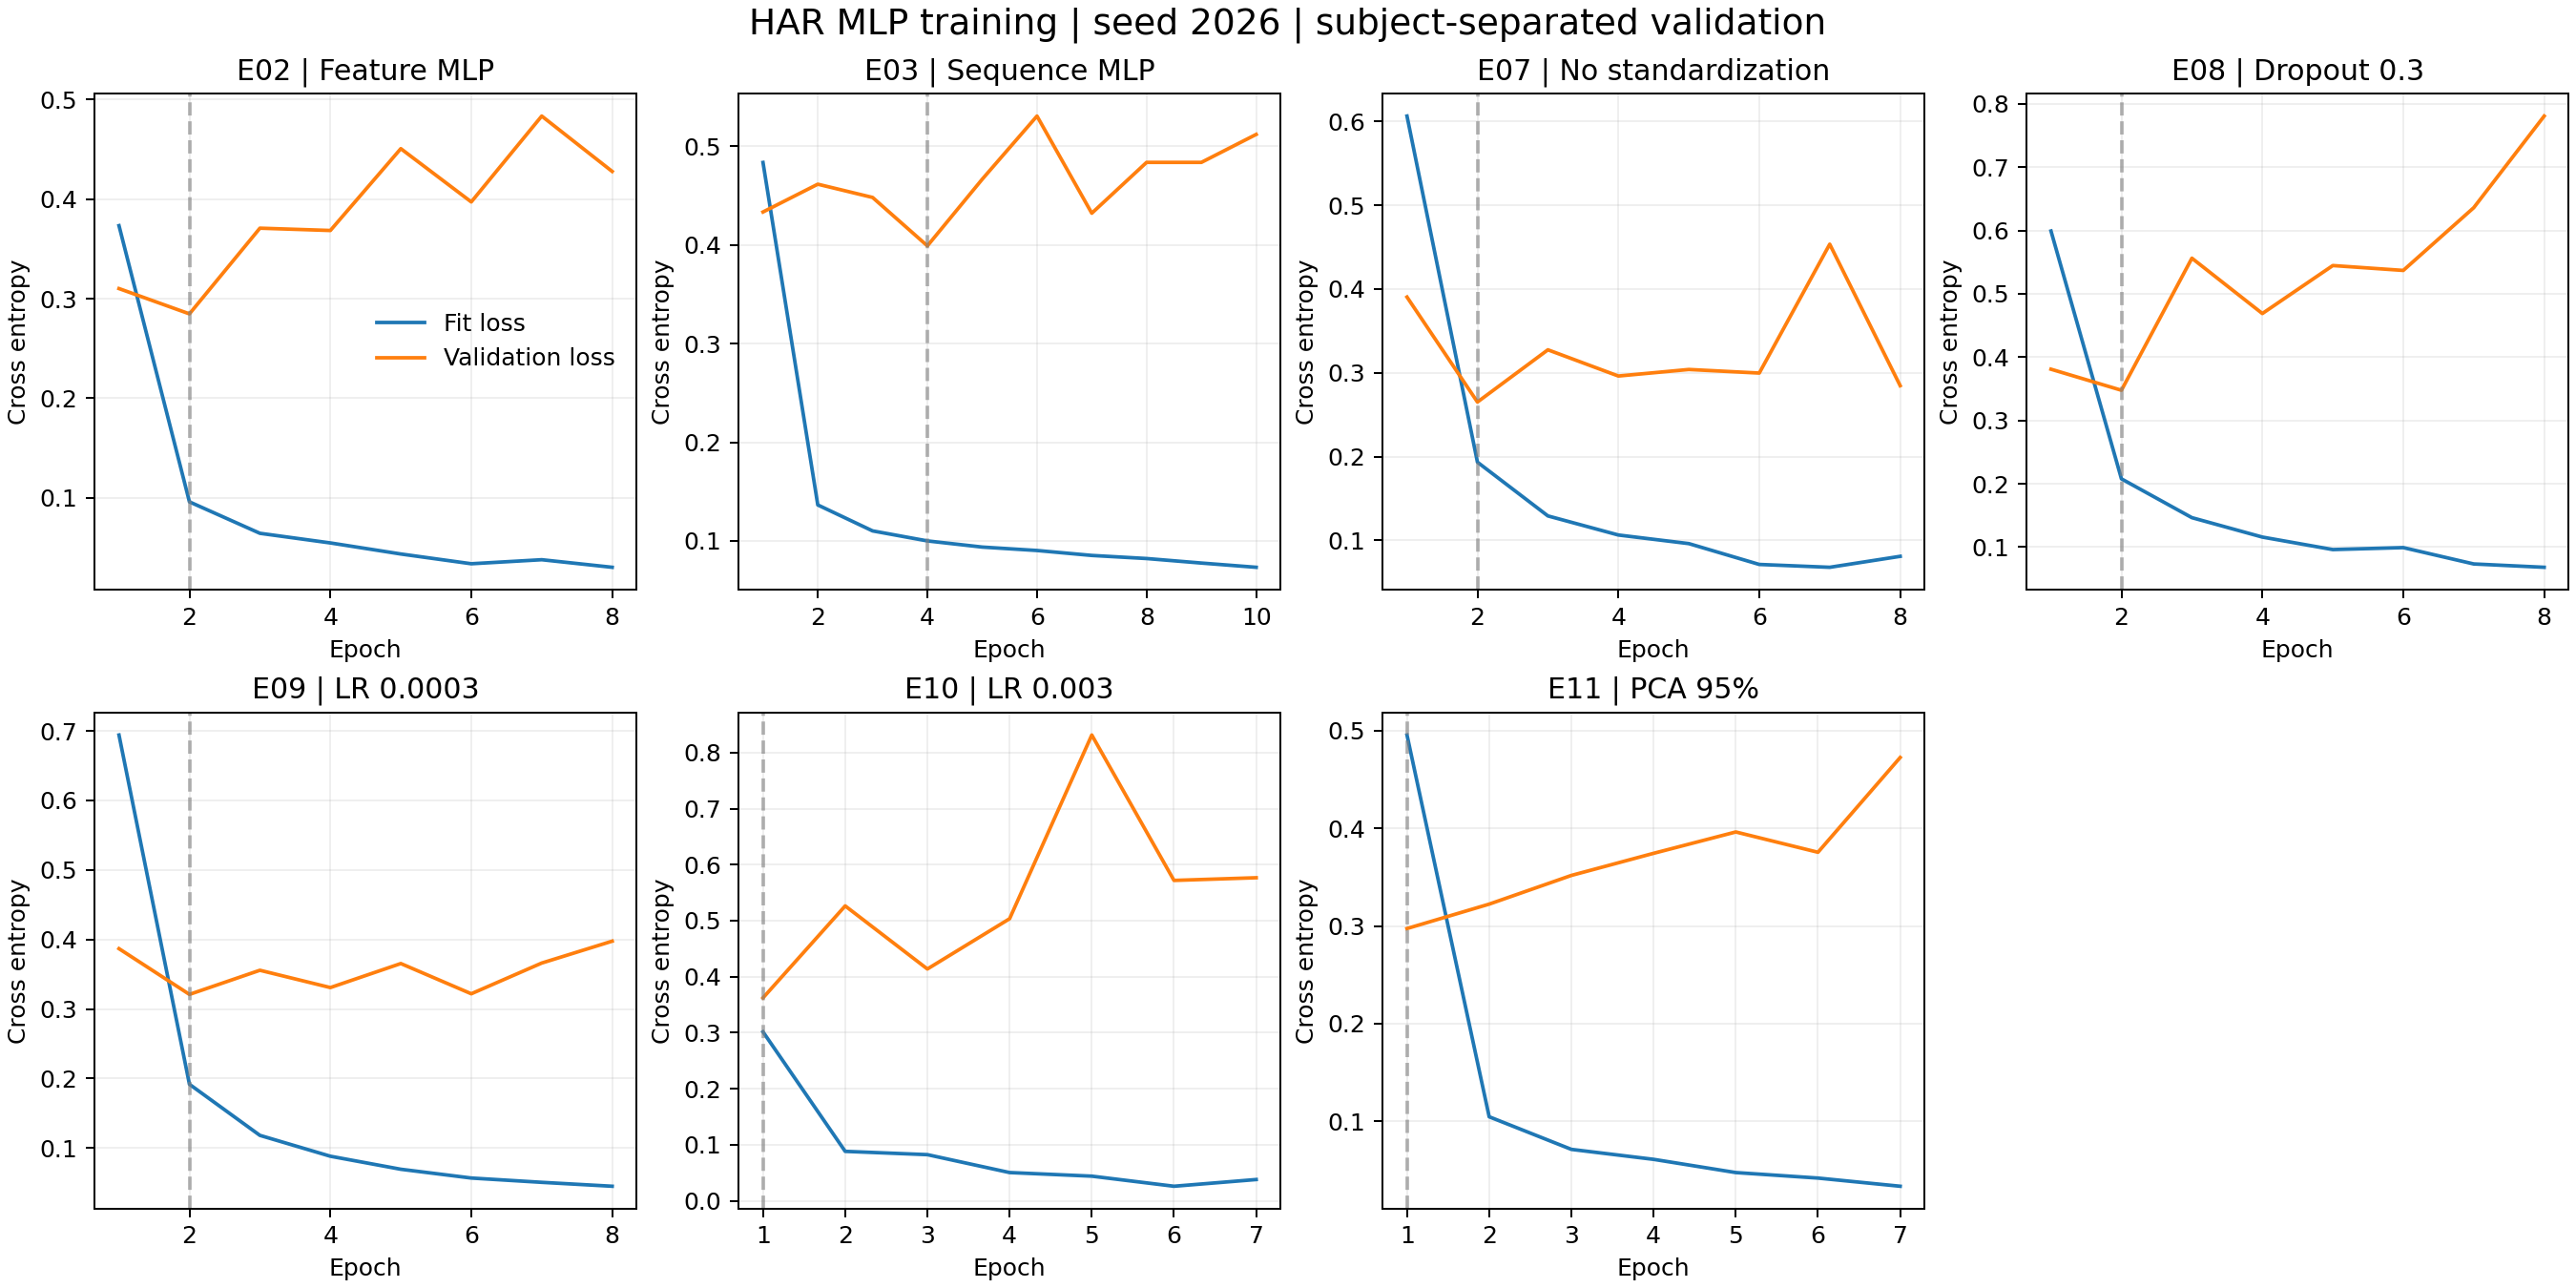

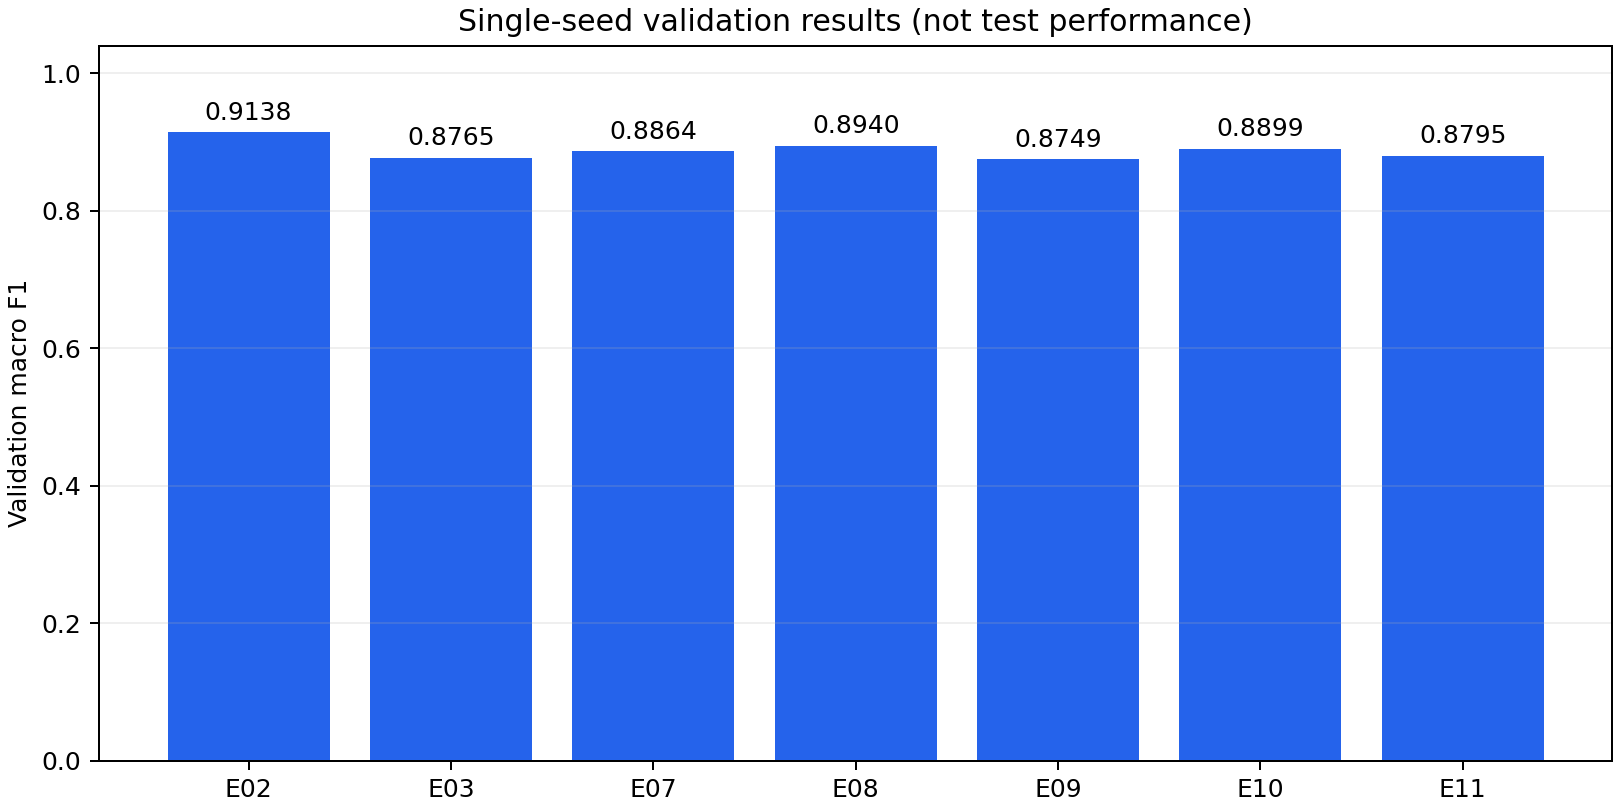

In [3]:
display(Image(filename=str(ROOT / "reports/learning_curves.png")))
display(Image(filename=str(ROOT / "reports/validation_f1.png")))

## 바꾼 것과 유지한 것
E07은 표준화만 제거, E08은 두 은닉층에 Dropout 0.3, E09와 E10은 학습률만 변경한다. E11은 PCA 95%를 사용하며 입력 차원과 첫 층 파라미터 수가 함께 달라진다. E03은 특징 벡터 대신 시계열 입력을 사용하므로 구조만의 비교가 아니다.

In [4]:
baseline = float(rows[0]["macro_f1"])
for row in rows[1:]:
    print(row["experiment"], "delta macro F1 (percentage points):", round(100*(float(row["macro_f1"])-baseline), 2))

E03 delta macro F1 (percentage points): -3.73
E07 delta macro F1 (percentage points): -2.74
E08 delta macro F1 (percentage points): -1.99
E09 delta macro F1 (percentage points): -3.9
E10 delta macro F1 (percentage points): -2.4
E11 delta macro F1 (percentage points): -3.43


## 질문에 답하기
1. 검증 손실이 최소인 epoch와 학습을 멈춘 epoch는 왜 다른가?
2. 학습 손실은 감소하지만 검증 손실이 증가하면 어떤 원인을 의심하는가?
3. Dropout 또는 작은 학습률의 효과가 이 데이터와 seed에서 어떻게 나타났는가?
4. PCA의 큰 분산 보존이 높은 분류 성능을 보장하지 않는 이유는 무엇인가?
5. 반복 seed와 공식 시험 평가 없이 주장할 수 있는 범위는 어디까지인가?

관측값은 reports/RESULTS_KO.md와 대조한다. 단일 seed 결과를 전체 팀 최종 모델 선택이나 통계적 우월성으로 확대하지 않는다.